# TorchSig Bounding Box Validation Quality Checks

Two independent checks on the bounding-box labels TorchSig can attach to signals it generates, for **each signal class** in the library.

| | What it does | What you get |
|---|---|---|
| **Task 1: Manual Verification** | One clean scene per class: single signal, no impairments or Component Transforms, very high SNR. Plots the spectrogram with its box overlaid and writes a PNG. | A folder of images to visually inspect. |
| **Task 2: Automatic Verification** | Configurable number of scenes per class. Independently estimates energy fraction within bounding box and the slack in both time and frequency. | Per-class and overall statistics. |

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from torchsig.transforms.transforms import Spectrogram
from torchsig.transforms.metadata_transforms import YOLOLabel
from torchsig.signals.signal_lists import TorchSigSignalLists
from torchsig.datasets import TorchSigIterableDataset
from torchsig.utils.defaults import default_dataset

### Global Configuration

In [10]:
SEED = 1234567890               # seed for random generators

# Scene variables
SAMPLE_RATE       = 10e6        # Hz
FFT_SIZE          = 512         # FFT dimension
NUM_IQ_SAMPLES    = 512 * 512   # 262144 -> a 512x512 spectrogram at fft_size 512
SNR_DB            = 50.0        # very high SNR so a signal dominates a scene
IMPAIRMENT_LEVEL  = 0           # 0 = clean signals without impairments

# Leave as None to accept TorchSig's own duration/bandwidth ranges (recommended:
# it exercises the labels over the range the library actually produces)
SIGNAL_DURATION_MIN   = None    # samples
SIGNAL_DURATION_MAX   = None    # samples
SIGNAL_BANDWIDTH_MIN  = None    # Hz
SIGNAL_BANDWIDTH_MAX  = None    # Hz

# dataset metadata
METADATA = {
    "num_iq_samples_dataset": 262144,  # 512**2
    "num_signals_min": 1,
    "num_signals_max": 1,
    "fft_size": 512,
    "fft_stride": 512,
    "sample_rate": 10000000,
    "noise_power_db": 0.0,
    "snr_db_min": 50.0,
    "snr_db_max": 50.0,
    "cochannel_overlap_probability": 0.0,
    "signal_duration_in_samples_min": 262144 * 0.8,
    "signal_duration_in_samples_max": 262144 * 1.0,
    "bandwidth_min": 2500000,
    "bandwidth_max": 3333333,
    "signal_center_freq_min": -2500000,
    "signal_center_freq_max": 2499999,
    "frequency_min": -2500000,
    "frequency_max": 2499999,
}

# Task 2 variables
NUM_SCENES_PER_CLASS = 10       # spectrograms generated per signal class
TARGET_CONTAINMENT = 0.997      # containment a trimmed box must still hold (3 sigma)
TRIM_WARN          = 0.10       # flag a class that could give back this much
TARGET_LO, TARGET_HI = 0.95, 0.99  # band a healthy box should land in


# location to write generated images for Task 1 Manual Verification
os.makedirs("bbox_images", exist_ok=True)

### Support Functions

In [3]:
def to_boxes(label):
    """Normalize a yolo_label target into an (N, 5) array of (cid, cx, cy, w, h)."""
    if label is None:
        return np.empty((0, 5))
    arr = np.asarray(label, dtype=float)
    if arr.ndim == 1:
        # single box (5,) -> (1,5); empty/degenerate -> (0,5)
        arr = arr.reshape(1, 5) if arr.size == 5 else arr.reshape(0, 5)
    return arr


def yolo_to_pixel_box(cx, cy, w, h, W, H):
    """Convert a normalized YOLO box to matplotlib imshow data coordinates.

    Time:  frames tile [0, num_iq) with no overlap, so frame j covers samples
           [j*N, (j+1)*N) and is centered at normalized time (j+0.5)/W.
           Inverting, normalized t -> column j = t*W - 0.5.

    Freq:  after fftshift + [::-1], row i holds frequency (H/2 - 1 - i)*fs/H,
           so row i = H/2 - 1 - f*H/fs. YOLOLabel emits y = 0.5 - f/fs,
           which assumes a symmetric [-fs/2, +fs/2] axis. Substituting gives
           row = y*H - 1.0.

    Returns ((x_lower_left, y_upper_left), width_px, height_px) for Rectangle.
    """
    x_center = cx * W - 0.5
    y_center = cy * H - 1.0
    box_w = w * W
    box_h = h * H
    return (x_center - box_w / 2.0, y_center - box_h / 2.0), box_w, box_h


def energy_ratio(spec_db, box):
    """Fraction of a scene's total energy that falls inside its bounding box.

    One signal per scene at ~50 dB SNR, so the noise floor carries well under
    0.01 % of the energy and the whole spectrogram is effectively that one
    signal. No noise subtraction, which also keeps the ratio inside [0, 1].
    """
    power = 10.0 ** (np.asarray(spec_db, dtype=np.float64) / 10.0)
    H, W = power.shape

    cid, cx, cy, w, h = box
    (x0, y0), box_w, box_h = yolo_to_pixel_box(cx, cy, w, h, W, H)
    c0, c1 = max(int(round(x0)), 0), min(int(round(x0 + box_w)), W)
    r0, r1 = max(int(round(y0)), 0), min(int(round(y0 + box_h)), H)

    return power[r0:r1, c0:c1].sum() / power.sum()


def _axis_slack(profile, lo, hi, target):
    """Containment of the span [lo, hi) in a 1-D energy profile, and how far
    that span could shrink and still hold `target` of the profile's energy.

    Returns (containment, narrowest_width_px, fractional_reduction).
    """
    if hi <= lo:
        return 0.0, 0, 0.0

    cum = np.concatenate(([0.0], np.cumsum(profile)))
    cum /= cum[-1]

    contained = cum[hi] - cum[lo]
    if contained < target:                      # nothing to trim
        return contained, hi - lo, 0.0

    a = np.arange(lo, hi)                       # every candidate left edge
    b = np.searchsorted(cum, cum[a] + target)   # tightest matching right edge
    keep = b <= hi                              # trimmed span stays in the box
    narrowest = int((b[keep] - a[keep]).min())
    return contained, narrowest, 1.0 - narrowest / (hi - lo)


def box_slack(spec_db, box, target=TARGET_CONTAINMENT):
    """Per-axis containment of a box, and the width/height reduction that would
    still leave `target` of the energy on that axis.

    Time uses the column energy profile (summed over all rows), frequency the
    row profile (summed over all columns), so the axes are measured separately.
    """
    power = 10.0 ** (np.asarray(spec_db, dtype=np.float64) / 10.0)
    H, W = power.shape

    cid, cx, cy, w, h = box
    (x0, y0), box_w, box_h = yolo_to_pixel_box(cx, cy, w, h, W, H)
    c0, c1 = max(int(round(x0)), 0), min(int(round(x0 + box_w)), W)
    r0, r1 = max(int(round(y0)), 0), min(int(round(y0 + box_h)), H)

    t_cont, t_px, t_red = _axis_slack(power.sum(axis=0), c0, c1, target)
    f_cont, f_px, f_red = _axis_slack(power.sum(axis=1), r0, r1, target)

    return {"time_containment": t_cont, "time_reduction": t_red, "time_px": t_px,
            "freq_containment": f_cont, "freq_reduction": f_red, "freq_px": f_px}

### Task 1: Manual Verification

In [ ]:
# Task 1 Baseline: no impairments or Component Transforms

# for each Signal of Interest, create a dataset, then generate an image
for i, cls in enumerate(TorchSigSignalLists.all_signals):
    ds = TorchSigIterableDataset(
        metadata=METADATA,
        component_transforms=[],
        transforms=[Spectrogram(fft_size=FFT_SIZE), YOLOLabel()],
        target_labels=["yolo_label"],   # yolo label format
        signal_generators=[str(cls)],   # single signal of interest
        validate_init=True
    )
    ds.seed(SEED + i) # fresh seed for each dataset/SoI

    # spec_db: wideband spectrogram in power dB
    # label: single element list of (cid,cx,cy,w,h) 
    spec_db, label = next(ds)          
    H, W = spec_db.shape

    # generate figure
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(spec_db, aspect="auto", origin='upper', 
        cmap="viridis", 
        vmin=ds.noise_power_db,
        vmax=ds.noise_power_db + SNR_DB
    )
    ax.set_title(cls)
    ax.set_ylabel('Frequency')
    ax.set_xlabel('Time')
    cbar = fig.colorbar(im, ax=ax, pad=0.02, extend="both")
    cbar.set_label("Power (dB)")

    # add bounding boxes
    for cid, cx, cy, w, h in to_boxes(label):
        (x0, y0), box_w, box_h = yolo_to_pixel_box(cx, cy, w, h, W, H)
        ax.add_patch(Rectangle((x0, y0), box_w, box_h,
                        fill=False, edgecolor="red", lw=1.0, clip_on=True))

    fig.savefig(f"bbox_images/{cls}.png", dpi=120); plt.close(fig)

### Task 2: Automatic Verification

In [7]:
stats = {} # statistics per SoI class
SLACK_KEYS = ("time_containment", "freq_containment", "time_reduction", "freq_reduction")

for i, cls in enumerate(TorchSigSignalLists.all_signals):
    ds = TorchSigIterableDataset(
        metadata=METADATA,              # same scene config as Task 1
        component_transforms=[],
        transforms=[Spectrogram(fft_size=FFT_SIZE), YOLOLabel()],
        target_labels=["yolo_label"],
        signal_generators=[str(cls)],   
        validate_init=True
    )
    ds.seed(SEED + i)
    
    ratios, slacks = [], []
    for _ in range(NUM_SCENES_PER_CLASS):
        spec_db, label = next(ds)
        for box in to_boxes(label):
            ratios.append(energy_ratio(spec_db, box))
            slacks.append(box_slack(spec_db, box))
    ratios = np.array(ratios)

    s = {
        "n":      ratios.size,
        "mean":   ratios.mean(),
        "std":    ratios.std(),
        "median": np.median(ratios),
        "min":    ratios.min(),
        "max":    ratios.max(),
        "ratios": ratios,
    }
    for k in SLACK_KEYS:
        s[k] = np.array([x[k] for x in slacks])
    stats[str(cls)] = s

    print(f"{str(cls):<22} energy {100*s['mean']:6.2f}%    trim required:  "
          f"time {100*np.median(s['time_reduction']):5.1f}%   "
          f"freq {100*np.median(s['freq_reduction']):5.1f}%", flush=True)

ook                    energy  99.63%    trim required:  time   0.2%   freq   3.0%
4ask                   energy  99.79%    trim required:  time   0.2%   freq  17.6%
8ask                   energy  99.78%    trim required:  time   0.2%   freq   9.9%
16ask                  energy  99.70%    trim required:  time   0.2%   freq   6.1%
32ask                  energy  99.70%    trim required:  time   0.2%   freq   2.7%
64ask                  energy  99.76%    trim required:  time   0.2%   freq   6.8%
2fsk                   energy  99.79%    trim required:  time   0.2%   freq  22.4%
2gfsk                  energy  99.81%    trim required:  time   0.3%   freq  46.8%
2msk                   energy  99.78%    trim required:  time   0.2%   freq  38.8%
2gmsk                  energy  99.88%    trim required:  time   0.2%   freq  48.3%
4fsk                   energy  99.74%    trim required:  time   0.2%   freq  22.8%
4gfsk                  energy  98.73%    trim required:  time   0.2%   freq  45.6%
4msk

In [11]:
# statistics
pooled = np.concatenate([s["ratios"] for s in stats.values()])
med = lambda name, key: float(np.median(stats[name][key]))


def status_of(name):
    s = stats[name]
    flags = []
    if float(np.median(s["ratios"])) < TARGET_LO:
        flags.append("SMALL")
    if med(name, "time_reduction") > TRIM_WARN:
        flags.append("WIDE")
    if med(name, "freq_reduction") > TRIM_WARN:
        flags.append("TALL")
    return " ".join(flags) if flags else "ok"


hdr = (f"{'signal':<22}{'n':>4}{'energy':>9}{'time':>9}{'freq':>9}"
       f"{'t-trim':>9}{'f-trim':>9}   status")
print(hdr)
print("-" * len(hdr))
print("(energy/time/freq = median containment;  t-trim/f-trim = median width or")
print(f" height that could be given back and still hold {100*TARGET_CONTAINMENT:.0f}% on that axis)\n")

for name in sorted(stats, key=lambda n: np.median(stats[n]["ratios"])):
    s = stats[name]
    print(f"{name:<22}{s['n']:>4}"
          f"{100*np.median(s['ratios']):>8.2f}%"
          f"{100*med(name, 'time_containment'):>8.2f}%"
          f"{100*med(name, 'freq_containment'):>8.2f}%"
          f"{100*med(name, 'time_reduction'):>8.1f}%"
          f"{100*med(name, 'freq_reduction'):>8.1f}%   {status_of(name)}")

t_red = np.concatenate([s["time_reduction"] for s in stats.values()])
f_red = np.concatenate([s["freq_reduction"] for s in stats.values()])
in_band = (pooled >= TARGET_LO) & (pooled <= TARGET_HI)
ok_classes = sum(status_of(n) == "ok" for n in stats)

print(f"\n{pooled.size} scenes over {len(stats)} classes")
print(f"energy ratio, pooled mean / median : "
      f"{100*pooled.mean():.2f}% / {100*np.median(pooled):.2f}%")
print(f"in {100*TARGET_LO:.0f}-{100*TARGET_HI:.0f}% band                    : "
      f"{100*in_band.mean():.1f}% of scenes")
print(f"trim required, median time / freq  : "
      f"{100*np.median(t_red):.1f}% / {100*np.median(f_red):.1f}%")
print(f"trim required, worst time / freq   : "
      f"{100*t_red.max():.1f}% / {100*f_red.max():.1f}%")
print(f"classes clean on both checks       : {ok_classes}/{len(stats)}")

signal                   n   energy     time     freq   t-trim   f-trim   status
--------------------------------------------------------------------------------
(energy/time/freq = median containment;  t-trim/f-trim = median width or
 height that could be given back and still hold 100% on that axis)

chirpss                 10   99.11%   99.86%   99.30%     0.4%     0.0%   ok
tone                    10   99.19%   99.76%   99.36%     0.1%     0.0%   ok
am-dsb                  10   99.54%   99.83%   99.67%     0.2%     0.0%   ok
adsb-long               10   99.60%   99.90%   99.71%     0.2%     1.4%   ok
adsb-short              10   99.61%   99.83%   99.74%     0.1%     4.6%   ok
ofdm-256                10   99.66%   99.82%   99.79%     0.2%    17.0%   TALL
ook                     10   99.67%   99.89%   99.76%     0.2%     3.0%   ok
dmr                     10   99.71%   99.95%   99.86%     0.2%     1.9%   ok
4gmsk                   10   99.71%   99.92%   99.95%     0.2%    33.7%   TALL


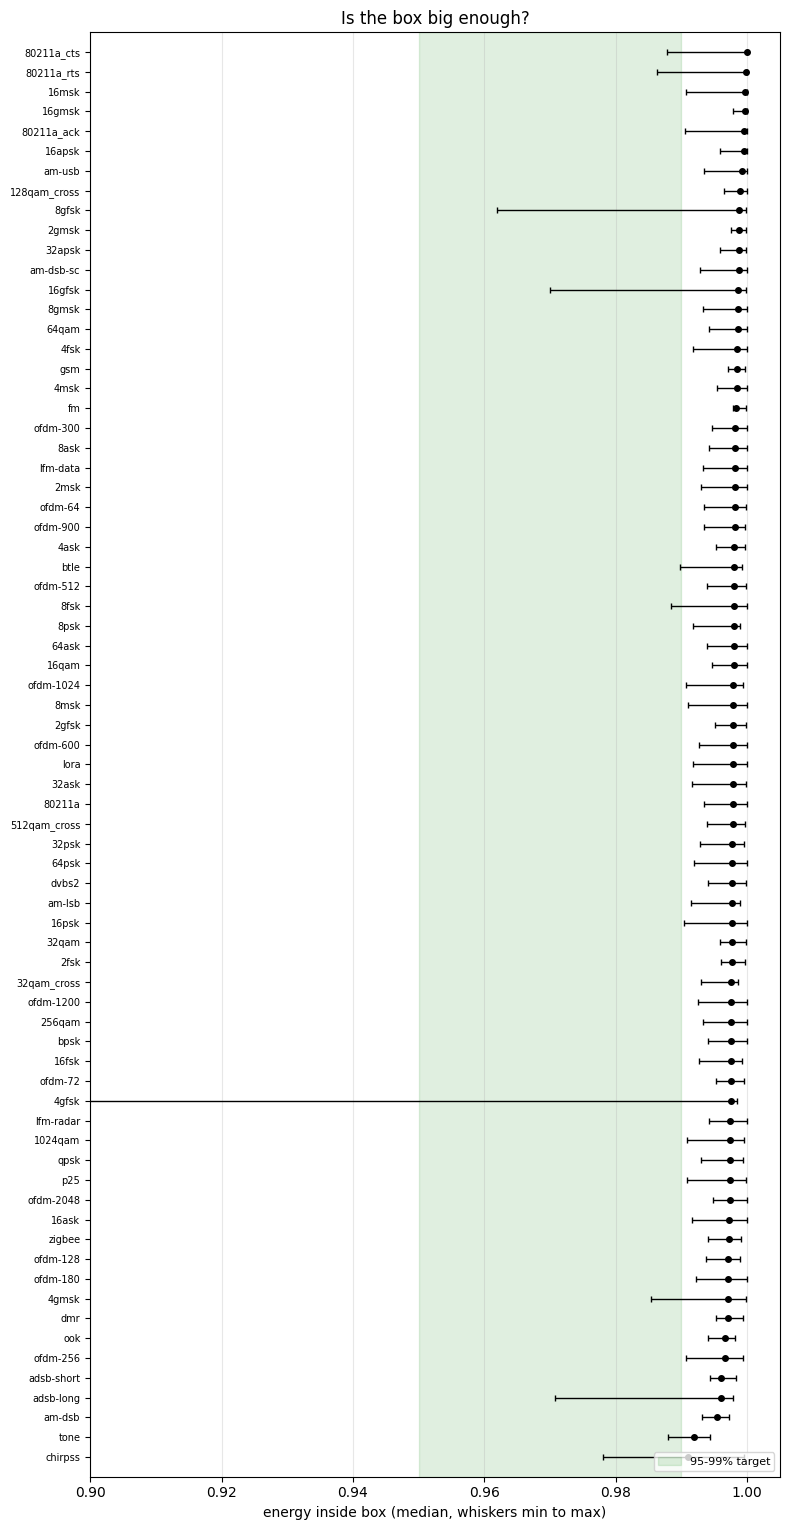

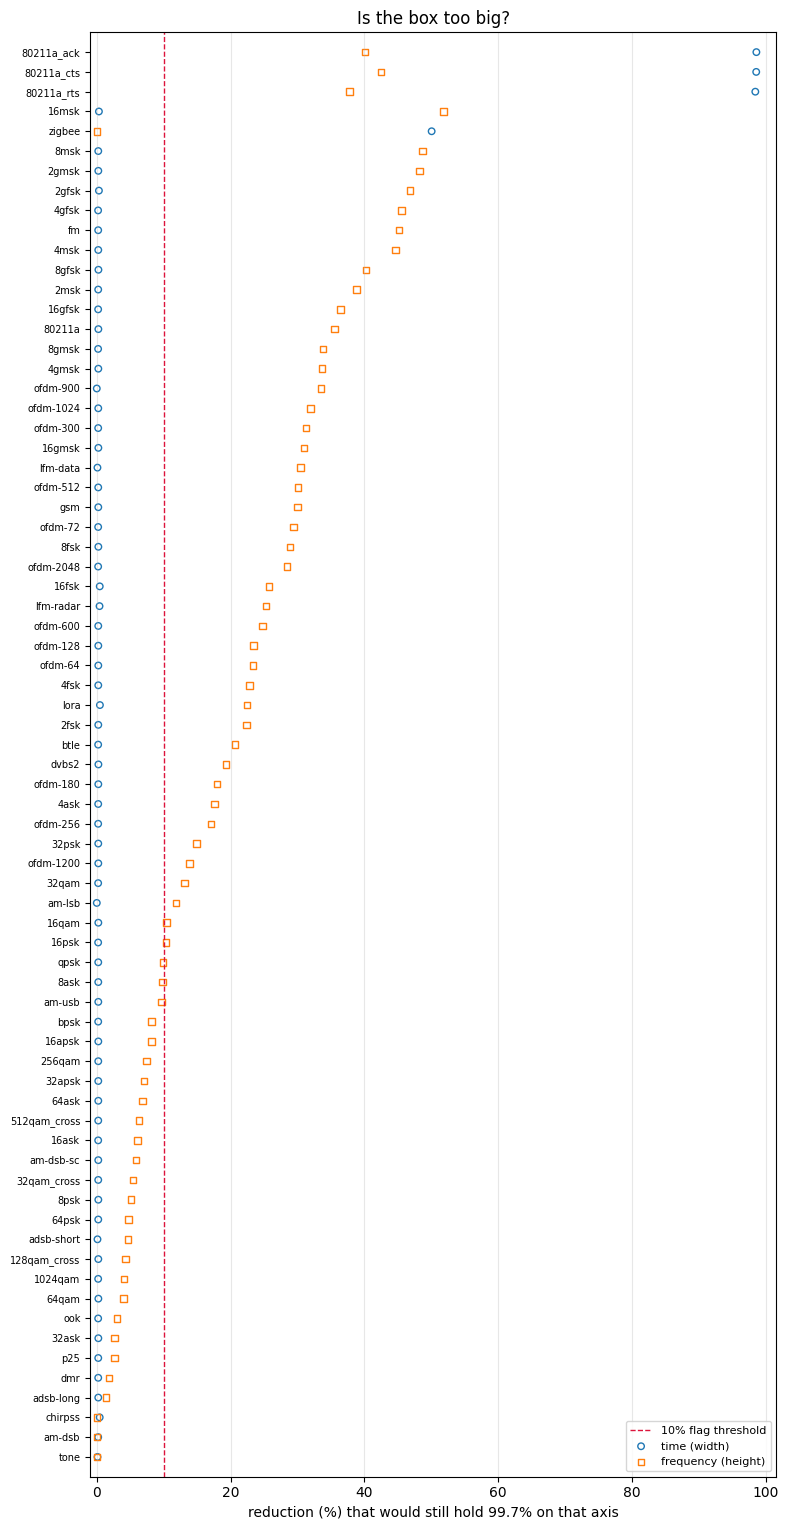

In [18]:
# containment: energy inside bounding box
names = sorted(stats, key=lambda n: np.median(stats[n]["ratios"]))
y     = np.arange(len(names))
m     = np.array([np.median(stats[n]["ratios"]) for n in names])
err   = np.vstack([m - np.array([stats[n]["min"] for n in names]),
                   np.array([stats[n]["max"] for n in names]) - m])

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.20 * len(names) + 1.0)))
ax.axvspan(TARGET_LO, TARGET_HI, color="green", alpha=0.12,
           label=f"{100*TARGET_LO:.0f}-{100*TARGET_HI:.0f}% target")
ax.errorbar(m, y, xerr=err, fmt="o", ms=4, lw=1, capsize=2, color="k")
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=7)
ax.set_ylim(-1, len(names)); ax.set_xlim(min(0.90, m.min() - 0.03), 1.005)
ax.set_xlabel("energy inside box (median, whiskers min to max)")
ax.set_title("Is the box big enough?")
ax.grid(axis="x", alpha=0.3); ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("bbox_images/containment_by_class.png", dpi=120)
plt.show()

# slack estimates: bounding box slack in time and frequency
names = sorted(stats, key=lambda n: max(med(n, "time_reduction"),
                                        med(n, "freq_reduction")))
y  = np.arange(len(names))
tr = np.array([med(n, "time_reduction") for n in names])
fr = np.array([med(n, "freq_reduction") for n in names])

fig, ax = plt.subplots(figsize=(8, max(4.0, 0.20 * len(names) + 1.0)))
ax.axvline(100 * TRIM_WARN, color="crimson", lw=1, ls="--",
           label=f"{100*TRIM_WARN:.0f}% flag threshold")
ax.scatter(100 * tr, y, s=22, marker="o", facecolors="none",
           edgecolors="tab:blue", label="time (width)")
ax.scatter(100 * fr, y, s=22, marker="s", facecolors="none",
           edgecolors="tab:orange", label="frequency (height)")
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=7)
ax.set_ylim(-1, len(names))
ax.set_xlim(-1.0, 100 * max(0.15, tr.max(), fr.max()) + 3.0)
ax.set_xlabel(f"reduction (%) that would still hold "
              f"{100*TARGET_CONTAINMENT:.1f}% on that axis")
ax.set_title("Is the box too big?")
ax.grid(axis="x", alpha=0.3); ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
fig.savefig("bbox_images/trim_by_class.png", dpi=120)
plt.show()